# MODELO SARIMA e Previsões: Desvendando a Sazonalidade em Séries Temporais

## Introdução ao Modelo SARIMA

No notebook anterior, exploramos os modelos AR, MA e ARIMA, que são fundamentais para entender a dependência temporal em séries temporais. No entanto, muitas séries temporais do mundo real exibem padrões sazonais, ou seja, padrões que se repetem em intervalos de tempo fixos (por exemplo, mensalmente, trimestralmente, anualmente).

O modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average) é uma extensão poderosa do ARIMA que foi desenvolvida para lidar especificamente com esses componentes sazonais. Ele é denotado como SARIMA($p, d, q$)($P, D, Q$)$_m$, onde:

-   Não Sazonal (ARIMA):
    -   $p$: Ordem da componente AutoRegressiva não sazonal.
    -   $d$: Ordem da diferenciação não sazonal necessária para tornar a série estacionária.
    -   $q$: Ordem da componente de Médias Móveis não sazonal.

-   Sazonal:
    -   $P$: Ordem da componente AutoRegressiva sazonal.
    -   $D$: Ordem da diferenciação sazonal necessária para remover a sazonalidade.
    -   $Q$: Ordem da componente de Médias Móveis sazonal.
    -   $m$: Período sazonal da série (ex: 12 para dados mensais, 4 para trimestrais).

A diferenciação sazonal ($D$) é análoga à diferenciação não sazonal ($d$), mas aplicada a lags múltiplos do período sazonal $m$. Por exemplo, uma diferenciação sazonal de ordem 1 para dados mensais ($m=12$) significaria subtrair o valor de 12 meses atrás do valor atual: $X_t - X_{t-12}$.

### Quando Usar SARIMA?

O SARIMA é apropriado quando sua série temporal apresenta:
1.  Não Estacionaridade: Tendências ou mudanças na média/variância (necessitando de $d$).
2.  Sazonalidade: Padrões repetitivos em intervalos fixos (necessitando de $D$).
3.  Autocorrelação: Dependência dos valores passados, tanto para componentes não sazonais ($p, q$) quanto sazonais ($P, Q$).

### Interpretação de ACF e PACF para SARIMA

A análise de ACF (Função de Autocorrelação) e PACF (Função de Autocorrelação Parcial) continua sendo crucial para identificar as ordens dos modelos, mas agora precisamos prestar atenção aos lags sazonais também:

-   Componentes Não Sazonais ($p, q$): Observar os picos e decaimentos nos primeiros lags da ACF e PACF após as diferenciações apropriadas.
-   Componentes Sazonais ($P, Q$): Observar os picos e decaimentos nos múltiplos do período sazonal ($m, 2m, 3m, \dots$) na ACF e PACF após as diferenciações apropriadas. Por exemplo, para dados mensais, procure por picos nos lags 12, 24, 36, etc.

### Etapas para Modelagem SARIMA:

1.  Visualização e Decomposição: Inspecionar a série para tendências, sazonalidade e variância. A decomposição sazonal (`seasonal_decompose`) é muito útil aqui.
2.  Testes de Estacionaridade: Usar KPSS ou ADF para verificar estacionaridade não sazonal.
3.  Diferenciação Não Sazonal ($d$): Aplicar diferenciações até que a série se torne estacionária (sem tendência forte ou mudanças na média).
4.  Teste de Sazonalidade (nsdiffs): Verificar a necessidade de diferenciação sazonal.
5.  Diferenciação Sazonal ($D$): Aplicar diferenciações sazonais para remover o padrão sazonal.
6.  Análise de ACF e PACF (da série duplamente diferenciada): Identificar as ordens $p, q, P, Q$ observando os padrões nos lags regulares e sazonais.
7.  Ajuste do Modelo: Ajustar o modelo SARIMAX com as ordens identificadas.
8.  Análise dos Resíduos: Verificar se os resíduos são ruído branco (sem autocorrelação, estacionários e preferencialmente normalmente distribuídos).
9.  Previsão: Utilizar o modelo ajustado para fazer previsões futuras.

## 1. Configuração Inicial e Carregamento dos Dados
Nesta seção, importamos as bibliotecas necessárias para a análise de séries temporais e configuramos o tamanho padrão dos gráficos para melhor visualização. Em seguida, carregamos o famoso dataset 'AirPassengers', que é um exemplo clássico de série temporal com forte sazonalidade e tendência.

In [1]:
# Importando as bibliotecas necessárias
!pip install pmdarima

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from pmdarima.arima.utils import ndiffs, nsdiffs
from scipy.stats import shapiro
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings para melhor leitura do output

# Configurando o tamanho padrão dos gráficos para melhor visualização
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6


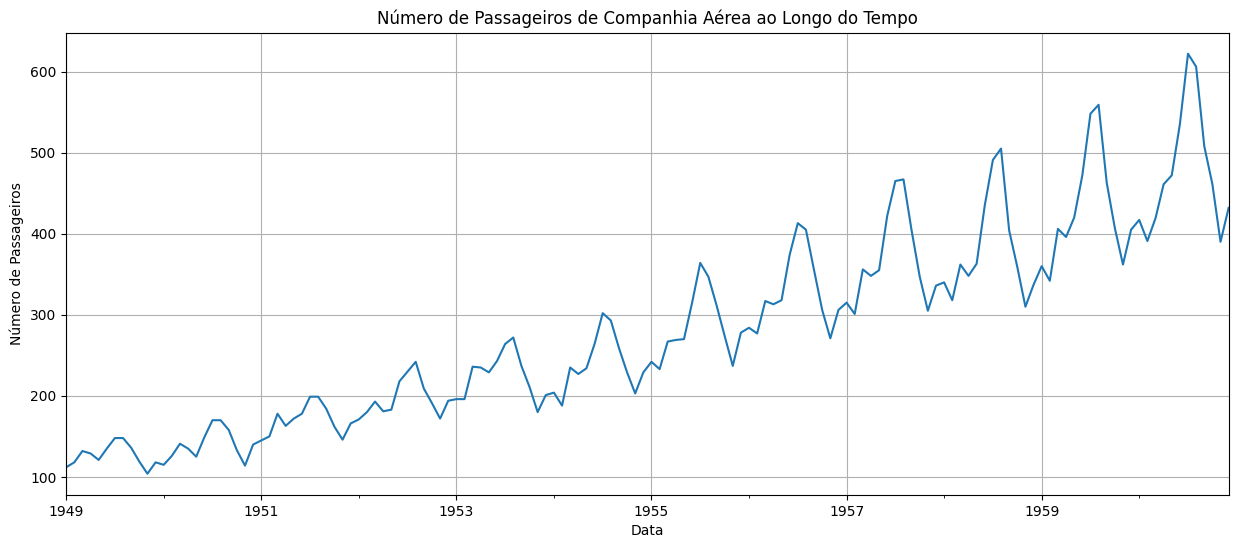

In [2]:
# Carregando a série AirPassengers
data_path = 'AirPassengers.csv' # Certifique-se de que este arquivo está no mesmo diretório
x = pd.read_csv(data_path, sep=',')

# Convertendo a coluna 'Month' para formato de data e definindo como índice
# O formato original é 'YYYY-MM', então usamos '%Y-%m'
x['Month'] = pd.to_datetime(x['Month'], format='%Y-%m')
x = x.set_index('Month')

# Selecionando a coluna 'Passengers' e garantindo que é uma Série Pandas
x = x['Passengers']

# Plotando a série temporal original
plt.figure(figsize=(rcParams['figure.figsize']))
x.plot(title='Número de Passageiros de Companhia Aérea ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.grid(True)
plt.show()


## 2. Decomposição da Série Temporal
A decomposição de uma série temporal permite separar seus componentes aditivos ou multiplicativos: tendência, sazonalidade e resíduos. Isso é crucial para entender a estrutura dos dados e orientar a escolha do modelo.

Para a série AirPassengers, que mostra um aumento na amplitude das flutuações sazonais ao longo do tempo, um modelo multiplicativo (`model='multiplicative'`) é mais adequado. Se a amplitude sazonal fosse constante, um modelo aditivo (`model='additive'`) seria preferível.

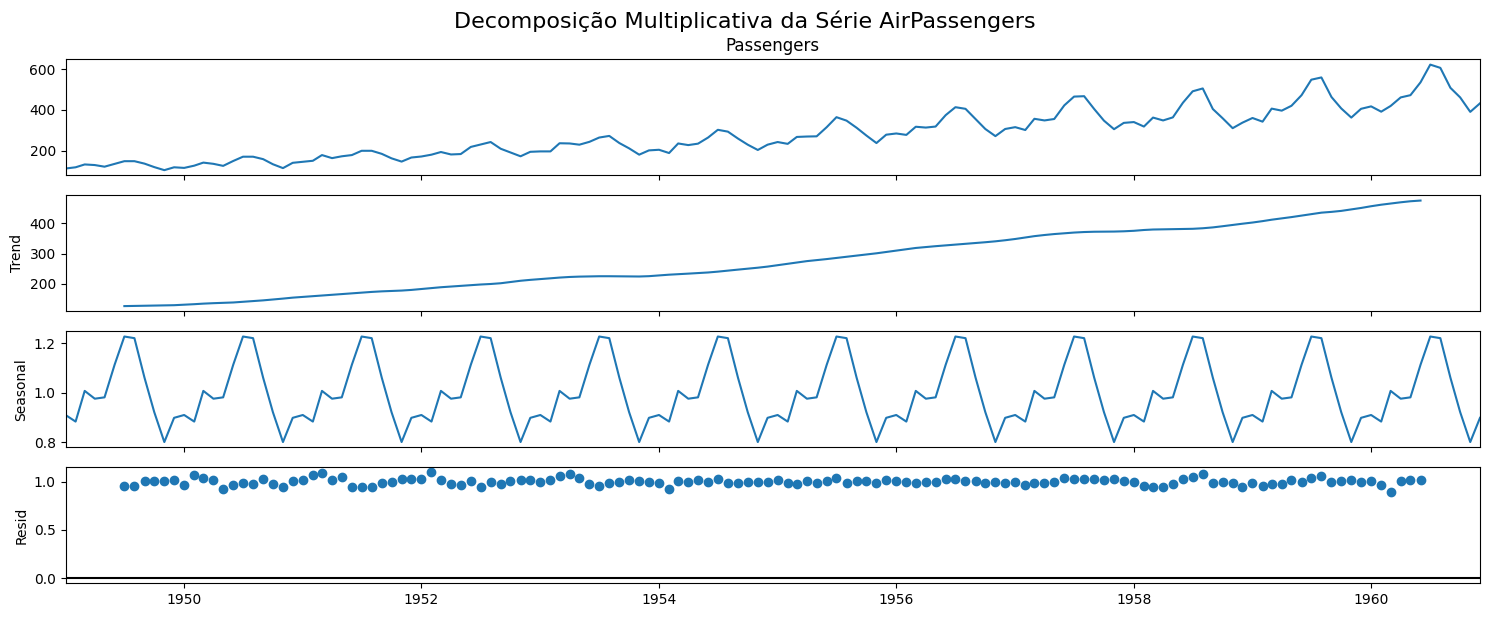

In [3]:
# Decomposição da série em tendência, sazonalidade e resíduos
decomposition = seasonal_decompose(x, model='multiplicative', period=12) # Periodo de 12 para dados mensais

# Plotando os componentes da decomposição
fig = decomposition.plot()
#fig.set_size_inches(rcParams['figure.figsize'][0], rcParams['figure.figsize'][1]*2) # Ajusta o tamanho para caber tudo
plt.suptitle('Decomposição Multiplicativa da Série AirPassengers', y=1.02, fontsize=16)
#plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar layout para não cortar o título
plt.show()


## 3. Testes de Estacionaridade e Determinação de Ordens de Diferenciação
A estacionaridade é uma premissa fundamental para muitos modelos de séries temporais, incluindo SARIMA. Uma série é estacionária se suas propriedades estatísticas (média, variância, autocorrelação) não mudam ao longo do tempo.

Utilizaremos os testes KPSS e ADF para avaliar a estacionaridade da série original e diferenciada. Além disso, as funções `ndiffs` e `nsdiffs` do `pmdarima` nos ajudarão a determinar as ordens de diferenciação não sazonal ($d$) e sazonal ($D$) automaticamente.

### 3.1. Teste KPSS na Série Original
O Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) testa a hipótese nula de que a série é estacionária em torno de uma média ou tendência. Um p-valor baixo (e.g., $< 0.05$) sugere que a série não é estacionária.

In [4]:
print('Teste KPSS na Série Original:')
kpss_stat, p_value, lags, critical_values = kpss(x, regression='c') # 'c' para estacionaridade de nível
print(f'Estatística do teste: {kpss_stat:.4f}')
print(f'p-valor: {p_value:.4f}')
print('Valores Críticos:')
for key, value in critical_values.items():
    print(f'{key}: {value:.4f}')

if p_value < 0.05:
    print("\nConclusão: Rejeitamos a hipótese nula (H0). A série NÃO É ESTACIONÁRIA (provavelmente com tendência ou raiz unitária).")
else:
    print("\nConclusão: Falhamos em rejeitar a hipótese nula (H0). A série É ESTACIONÁRIA.")


Teste KPSS na Série Original:
Estatística do teste: 1.6513
p-valor: 0.0100
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390

Conclusão: Rejeitamos a hipótese nula (H0). A série NÃO É ESTACIONÁRIA (provavelmente com tendência ou raiz unitária).


### 3.2. Determinação das Ordens de Diferenciação ($d$ e $D$)
Usaremos `ndiffs` para determinar a ordem de diferenciação não sazonal ($d$) e `nsdiffs` para a ordem de diferenciação sazonal ($D$).

-   `ndiffs(series, test='kpss')`: Calcula o número de diferenciações não sazonais para tornar a série estacionária, usando o teste KPSS.
-   `nsdiffs(series, m=period, test='ocsb')`: Calcula o número de diferenciações sazonais, onde `m` é o período sazonal (12 para dados mensais) e `test='ocsb'` é um teste comum para estacionaridade sazonal.

In [5]:
print('Determinando a ordem de diferenciação não sazonal (d):')
d = ndiffs(x, test='kpss', max_d=5) # Max 5 diferenciações para evitar sobre-diferenciação
print(f'Número de diferenciações não sazonais necessárias (d): {d}')

print('\nDeterminando a ordem de diferenciação sazonal (D):')
m = 12 # Período sazonal para dados mensais (12 meses)
D = nsdiffs(x, m=m, test='ocsb', max_D=3) # Max 3 diferenciações sazonais
print(f'Número de diferenciações sazonais necessárias (D): {D}')


Determinando a ordem de diferenciação não sazonal (d):
Número de diferenciações não sazonais necessárias (d): 1

Determinando a ordem de diferenciação sazonal (D):
Número de diferenciações sazonais necessárias (D): 1


### 3.3. Aplicando as Diferenciações e Análise da Série Transformada
Aplicaremos as diferenciações não sazonal e sazonal. A ordem é importante: geralmente aplica-se a diferenciação não sazonal primeiro, depois a sazonal (ou vice-versa, dependendo da literatura, mas o `SARIMAX` do `statsmodels` lida bem com a ordem interna).

Vamos plotar a série resultante e suas ACF/PACF para observar se a estacionaridade foi alcançada e para identificar os possíveis valores de $p, q, P, Q$.

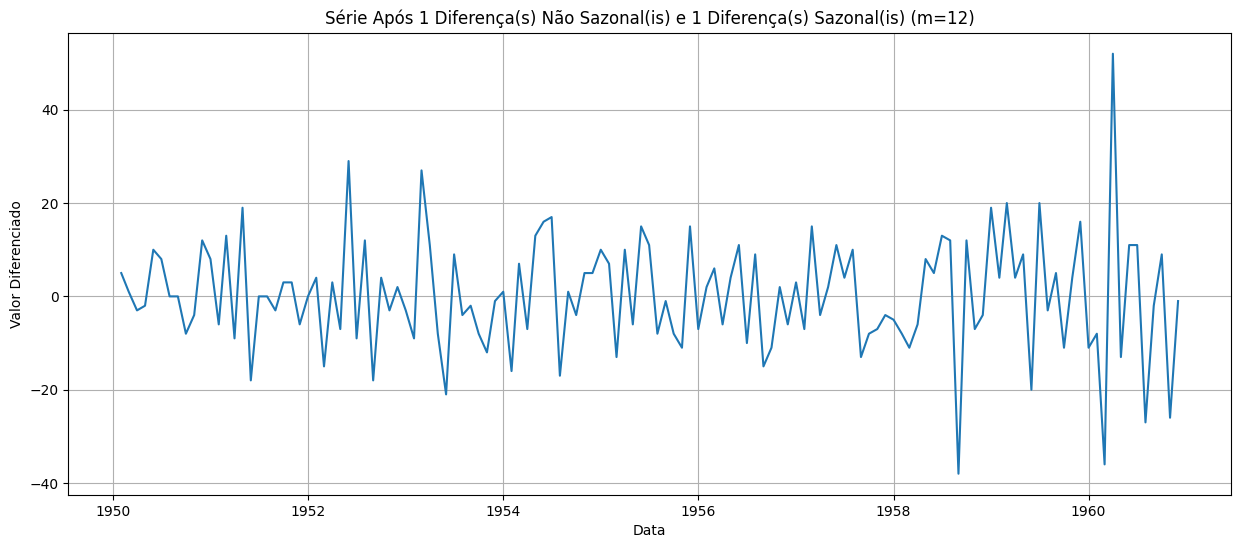


ACF e PACF da Série Duplamente Diferenciada:


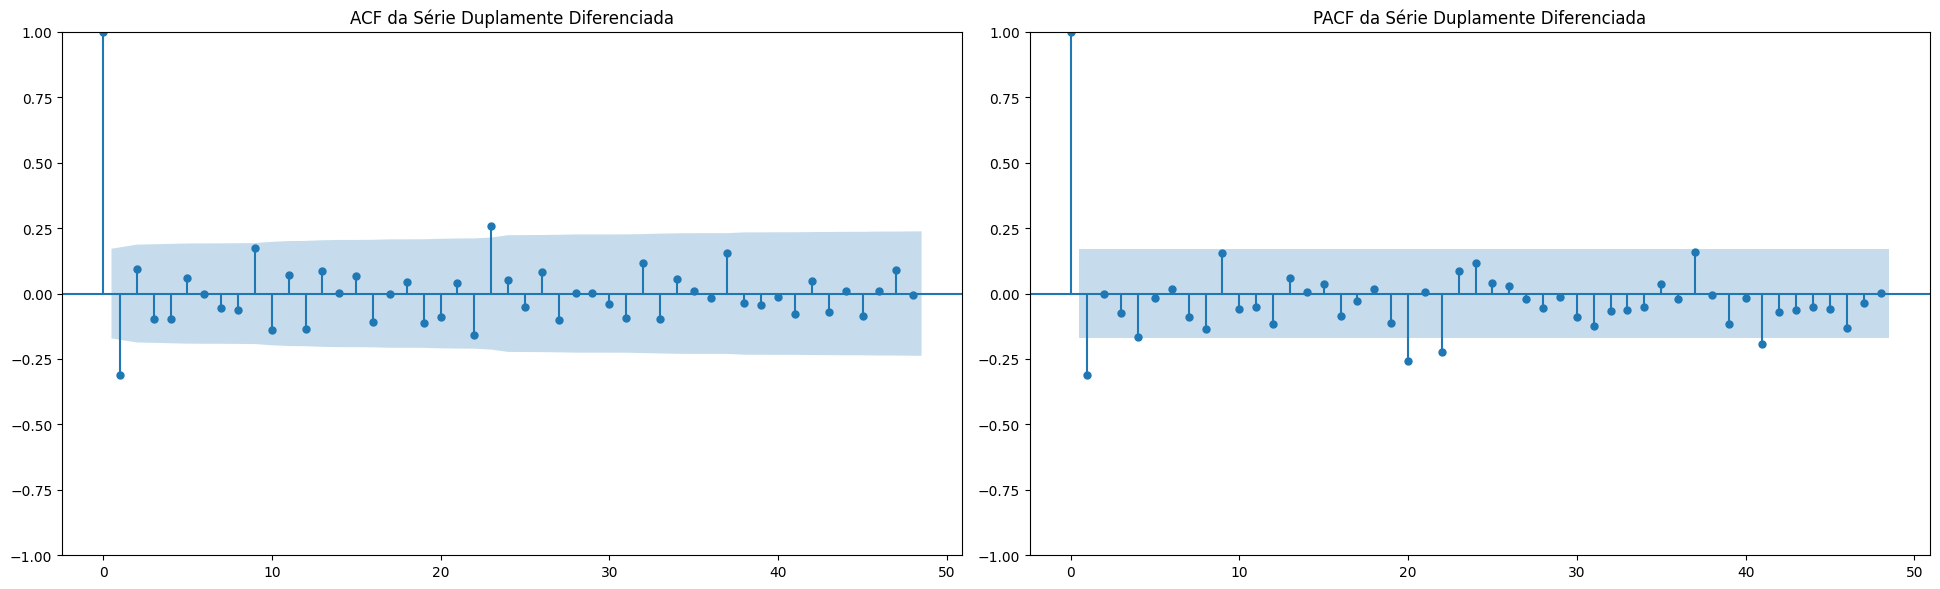

In [6]:
# Aplicando a diferenciação não sazonal e sazonal
# É importante aplicar as diferenciações na ordem correta. SARIMAX geralmente as aplica internamente.
# Para visualização, vamos aplicar as duas para ver a série transformada.
serie_dif = x.diff(d).dropna() # Aplica d diferenças não sazonais
serie_dif_sazonal = serie_dif.diff(m).dropna() # Aplica D diferenças sazonais (assumindo D=1 e m=12)

plt.figure(figsize=(rcParams['figure.figsize']))
plt.plot(serie_dif_sazonal)
plt.title(f'Série Após {d} Diferença(s) Não Sazonal(is) e {D} Diferença(s) Sazonal(is) (m={m})')
plt.xlabel('Data')
plt.ylabel('Valor Diferenciado')
plt.grid(True)
plt.show()

print('\nACF e PACF da Série Duplamente Diferenciada:')
fig, axes = plt.subplots(1, 2, figsize=(rcParams['figure.figsize'][0]*1.3, rcParams['figure.figsize'][1]))
plot_acf(serie_dif_sazonal, lags=4*m, ax=axes[0], title='ACF da Série Duplamente Diferenciada') # Lags suficientes para ver sazonalidade
plot_pacf(serie_dif_sazonal, lags=4*m, ax=axes[1], title='PACF da Série Duplamente Diferenciada')
plt.tight_layout()
plt.show()


### 3.4. Interpretação das ACF e PACF da Série Diferenciada
Agora, com a série transformada, podemos buscar os padrões nos gráficos de ACF e PACF para identificar as ordens $p, q, P, Q$.

-   ACF (Função de Autocorrelação): Mostra a correlação entre a série e suas versões defasadas. Um pico significativo no lag $k$ sugere um componente MA de ordem $k$.
-   PACF (Função de Autocorrelação Parcial): Mostra a correlação entre a série e suas versões defasadas, removendo a influência das correlações intermediárias. Um pico significativo no lag $k$ sugere um componente AR de ordem $k$.

Análise para AirPassengers (diferenciado):

Padrões Não Sazonais (Primeiros Lags):
-   ACF: Observar picos significativos nos primeiros lags (ex: lag 1, 2, 3...). Se um pico decai rapidamente após o lag 1, pode indicar um MA(1) não sazonal.
-   PACF: Observar picos significativos nos primeiros lags. Se um pico decai rapidamente após o lag 1, pode indicar um AR(1) não sazonal.

Padrões Sazonais (Lags Múltiplos de $m=12$):
-   ACF: Procurar por picos significativos nos lags 12, 24, 36... Se houver um corte abrupto no lag 12, sugere um MA(1) sazonal ($Q=1$).
-   PACF: Procurar por picos significativos nos lags 12, 24, 36... Se houver um corte abrupto no lag 12, sugere um AR(1) sazonal ($P=1$). Em muitos casos reais, pode ser necessário testar diferentes combinações.

## 4. Ajuste dos Modelos SARIMA Candidatos
Com base na análise de $d$, $D$, e dos gráficos ACF/PACF, podemos propor alguns modelos SARIMA candidatos. Usaremos a classe `SARIMAX` do `statsmodels` para ajustar os modelos.

Para a série AirPassengers, a literatura geralmente sugere modelos com componentes MA sazonal. Vamos testar dois modelos comuns:

-   Modelo 1: SARIMA(1,1,0)x(0,1,0)$_{12}$ (AR(1) não sazonal, 1 diferenciação não sazonal, nenhuma MA não sazonal; nenhuma AR sazonal, 1 diferenciação sazonal, nenhuma MA sazonal).
-   Modelo 2: SARIMA(0,1,1)x(0,1,1)$_{12}$ (Nenhuma AR não sazonal, 1 diferenciação não sazonal, MA(1) não sazonal; nenhuma AR sazonal, 1 diferenciação sazonal, MA(1) sazonal). Este é um modelo comum para AirPassengers.

In [7]:
print('Ajustando o Modelo 1: SARIMA(1,1,0)x(0,1,0)_12')
try:
    modelo1 = SARIMAX(x, order=(1, d, 0), seasonal_order=(0, D, 0, m), 
                      enforce_stationarity=False, enforce_invertibility=False).fit()
    E_mod1 = modelo1.resid
    print("Modelo 1 ajustado com sucesso.")
except Exception as e:
    print(f"Erro ao ajustar o Modelo 1: {e}")
    E_mod1 = None

Ajustando o Modelo 1: SARIMA(1,1,0)x(0,1,0)_12
Modelo 1 ajustado com sucesso.


### 4.1. Análise Visual dos Resíduos do Modelo 1
Os resíduos de um modelo bem ajustado devem ser ruído branco, ou seja, não devem apresentar padrões, serem independentes e normalmente distribuídos. Iremos visualizar os resíduos.

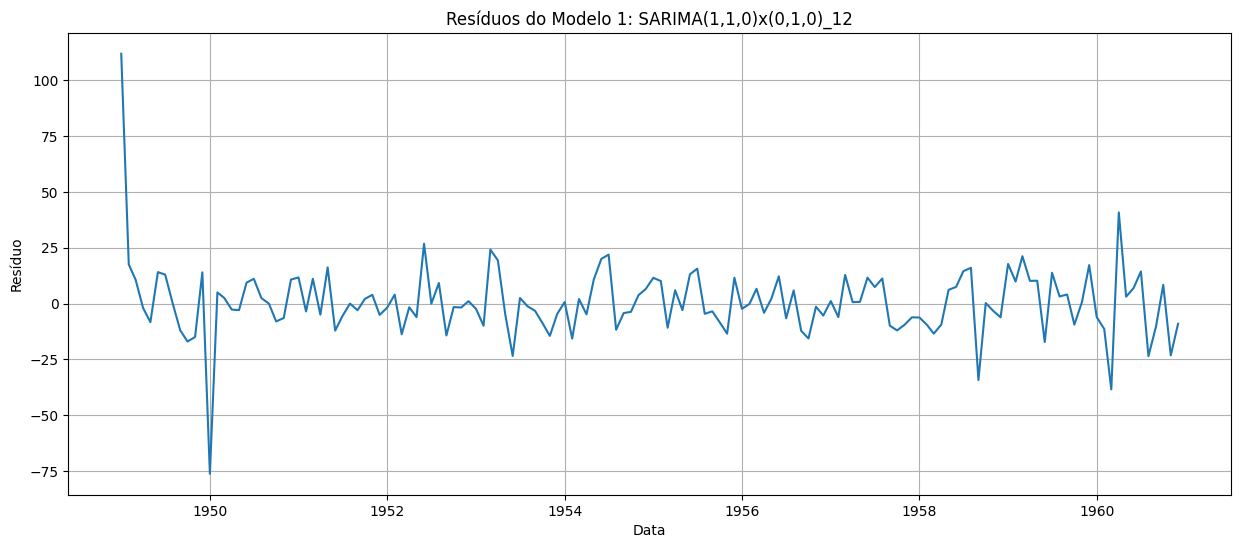

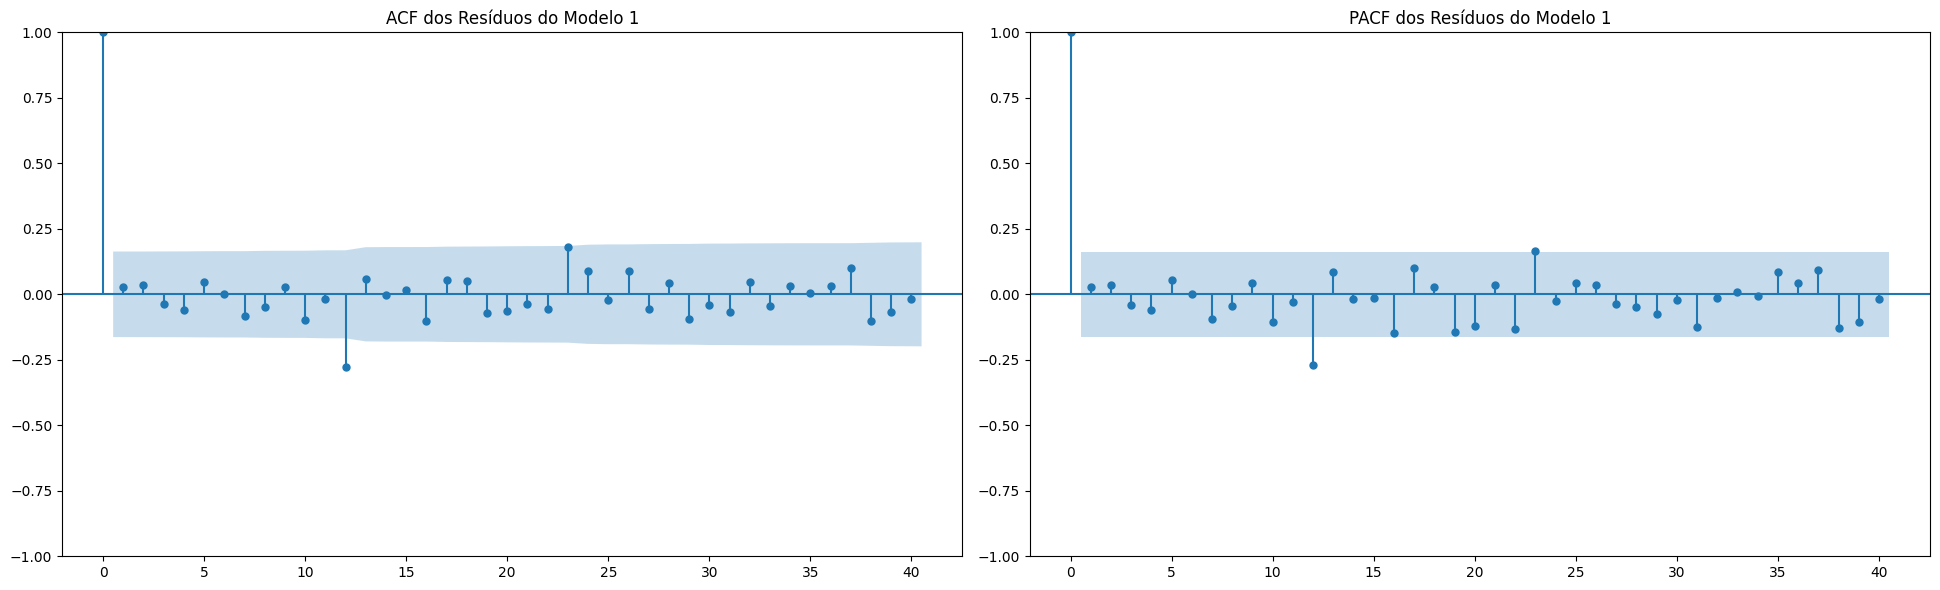

<Figure size 900x600 with 0 Axes>

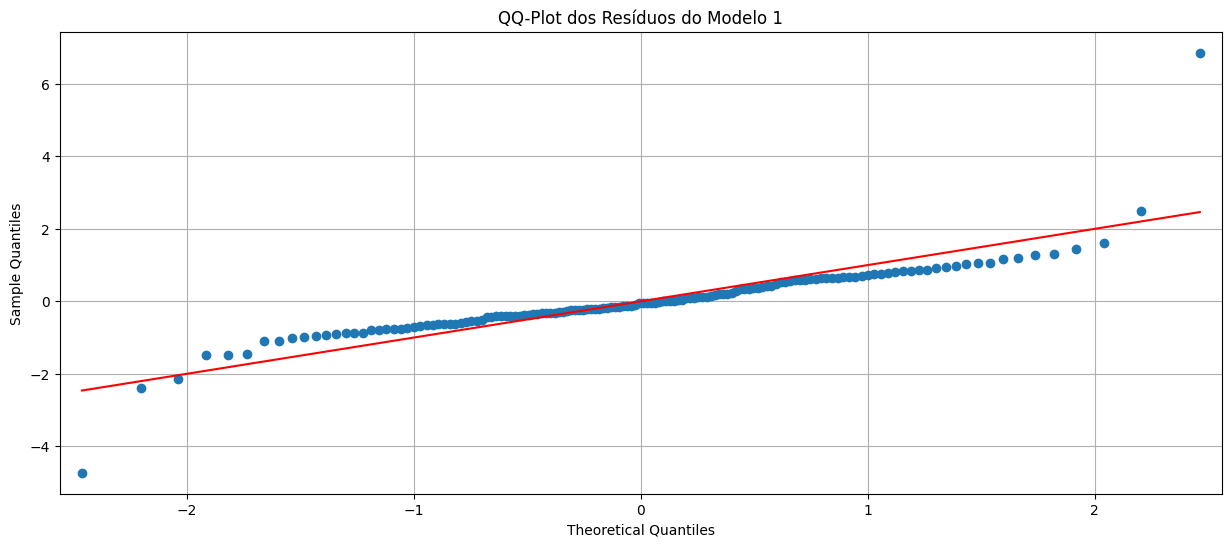

In [8]:
if E_mod1 is not None:
    # Remove os valores iniciais (d + m*D) que são 'NaN' ou resultantes da diferenciação
    E_mod1_clean = E_mod1.dropna()

    plt.figure(figsize=(rcParams['figure.figsize']))
    plt.plot(E_mod1_clean)
    plt.title('Resíduos do Modelo 1: SARIMA(1,1,0)x(0,1,0)_12')
    plt.xlabel('Data')
    plt.ylabel('Resíduo')
    plt.grid(True)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(rcParams['figure.figsize'][0]*1.3, rcParams['figure.figsize'][1]))
    plot_acf(E_mod1_clean, lags=40, ax=axes[0], title='ACF dos Resíduos do Modelo 1') # Lags suficientes
    plot_pacf(E_mod1_clean, lags=40, ax=axes[1], title='PACF dos Resíduos do Modelo 1')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(rcParams['figure.figsize'][0]*0.6, rcParams['figure.figsize'][1])) # Tamanho menor para QQ-Plot
    sm.qqplot(E_mod1_clean, line='s', fit=True)
    plt.title('QQ-Plot dos Resíduos do Modelo 1')
    plt.grid(True)
    plt.show()


### 4.2. Teste KPSS para Resíduos do Modelo 1
Verifica a estacionaridade dos resíduos. H0: A série é estacionária.

In [9]:
if E_mod1 is not None:
    E_mod1_clean = E_mod1.dropna()
    if len(E_mod1_clean) > 0: # Garante que há dados para testar
        print('Teste KPSS para Resíduos do Modelo 1:')
        kpss_stat, p_value, lags, critical_values = kpss(E_mod1_clean, regression='c')
        print(f'Estatística do teste: {kpss_stat:.4f}')
        print(f'p-valor: {p_value:.4f}')
        print('Valores Críticos:')
        for key, value in critical_values.items():
            print(f'{key}: {value:.4f}')
        if p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO ESTACIONÁRIOS.")
    else:
        print("Não há resíduos válidos para testar no Modelo 1.")

Teste KPSS para Resíduos do Modelo 1:
Estatística do teste: 0.0968
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.


### 4.3. Teste Ljung-Box para Resíduos do Modelo 1
Verifica a independência (ausência de autocorrelação) dos resíduos. H0: Os resíduos são ruído branco.

In [10]:
if E_mod1 is not None:
    E_mod1_clean = E_mod1.dropna()
    if len(E_mod1_clean) > 0: # Garante que há dados para testar
        print('Teste Ljung-Box para Resíduos do Modelo 1:')
        ljung_box_result = sm.stats.acorr_ljungbox(E_mod1_clean, lags=[min(40, len(E_mod1_clean) - 1)], return_df=True) 
        print(ljung_box_result)
        if ljung_box_result['lb_pvalue'].iloc[0] > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são INDEPENDENTES (ruído branco).")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.")
    else:
        print("Não há resíduos válidos para testar no Modelo 1.")

Teste Ljung-Box para Resíduos do Modelo 1:
      lb_stat  lb_pvalue
40  40.659608   0.441224
Conclusão: Falha ao rejeitar H0. Os resíduos são INDEPENDENTES (ruído branco).


### 4.4. Teste Shapiro-Wilk para Resíduos do Modelo 1
Verifica a normalidade dos resíduos. H0: Os resíduos são normalmente distribuídos.

In [11]:
if E_mod1 is not None:
    E_mod1_clean = E_mod1.dropna()
    if len(E_mod1_clean) >= 3: # Shapiro-Wilk requer pelo menos 3 pontos
        print('Teste Shapiro-Wilk para Resíduos do Modelo 1:')
        shapiro_stat, shapiro_p_value = shapiro(E_mod1_clean)
        print(f'Estatística do teste: {shapiro_stat:.4f}')
        print(f'p-valor: {shapiro_p_value:.4f}')
        if shapiro_p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são NORMALMENTE DISTRIBUÍDOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.")
    else:
        print("Não há dados suficientes nos resíduos para o teste Shapiro-Wilk no Modelo 1.")

Teste Shapiro-Wilk para Resíduos do Modelo 1:
Estatística do teste: 0.8072
p-valor: 0.0000
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.


In [13]:
print('Ajustando o Modelo 2: SARIMA(0,1,1)x(0,1,1)_12')
try:
    modelo2 = SARIMAX(x, order=(0, d, 1), seasonal_order=(0, D, 1, m), 
                      enforce_stationarity=False, enforce_invertibility=False).fit()
    E_mod2 = modelo2.resid
    print("Modelo 2 ajustado com sucesso.")
except Exception as e:
    print(f"Erro ao ajustar o Modelo 2: {e}")
    E_mod2 = None

Ajustando o Modelo 2: SARIMA(0,1,1)x(0,1,1)_12
Modelo 2 ajustado com sucesso.


### 4.5. Análise Visual dos Resíduos do Modelo 2
Repetimos a análise visual dos resíduos para o segundo modelo candidato.

In [14]:
E_mod2 = modelo2.resid
E_mod2_clean = E_mod2.dropna()

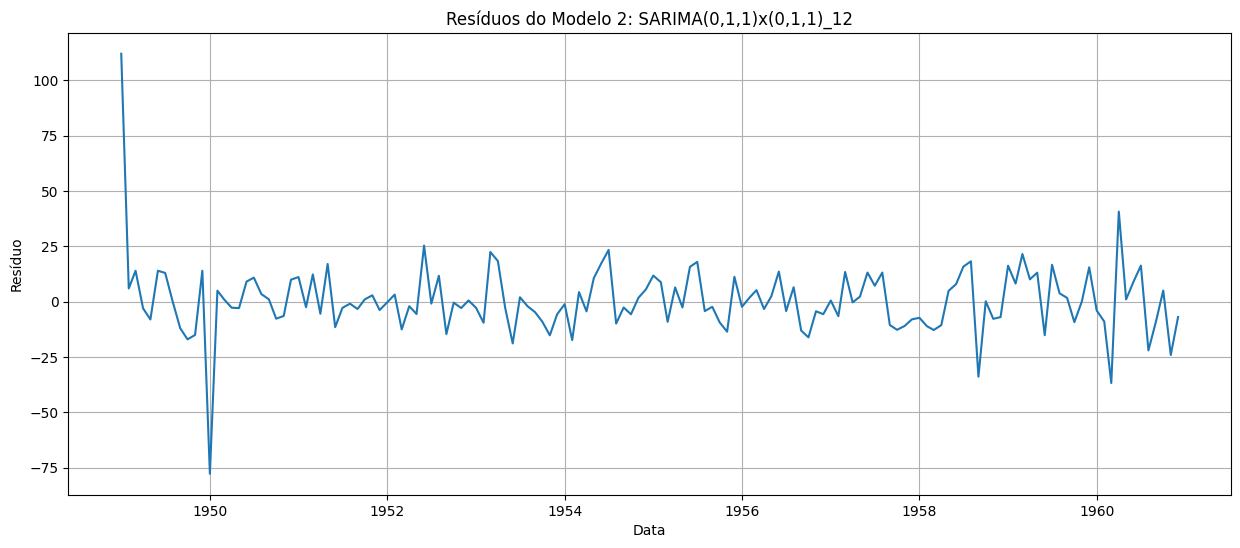

In [15]:
plt.figure(figsize=(rcParams['figure.figsize']))
plt.plot(E_mod2_clean)
plt.title('Resíduos do Modelo 2: SARIMA(0,1,1)x(0,1,1)_12')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.grid(True)
plt.show()

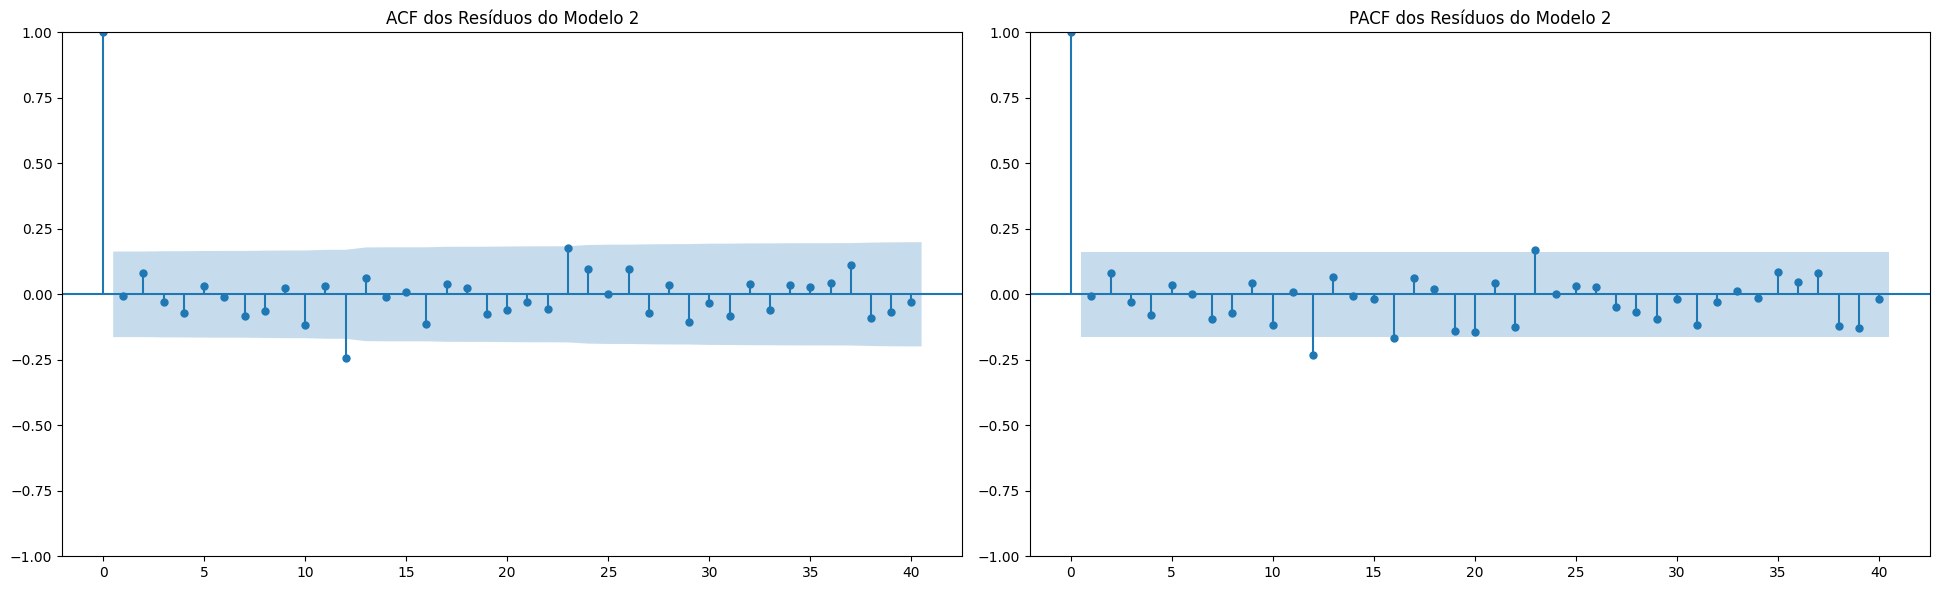

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(rcParams['figure.figsize'][0]*1.3, rcParams['figure.figsize'][1]))
plot_acf(E_mod2_clean, lags=40, ax=axes[0], title='ACF dos Resíduos do Modelo 2')
plot_pacf(E_mod2_clean, lags=40, ax=axes[1], title='PACF dos Resíduos do Modelo 2')
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

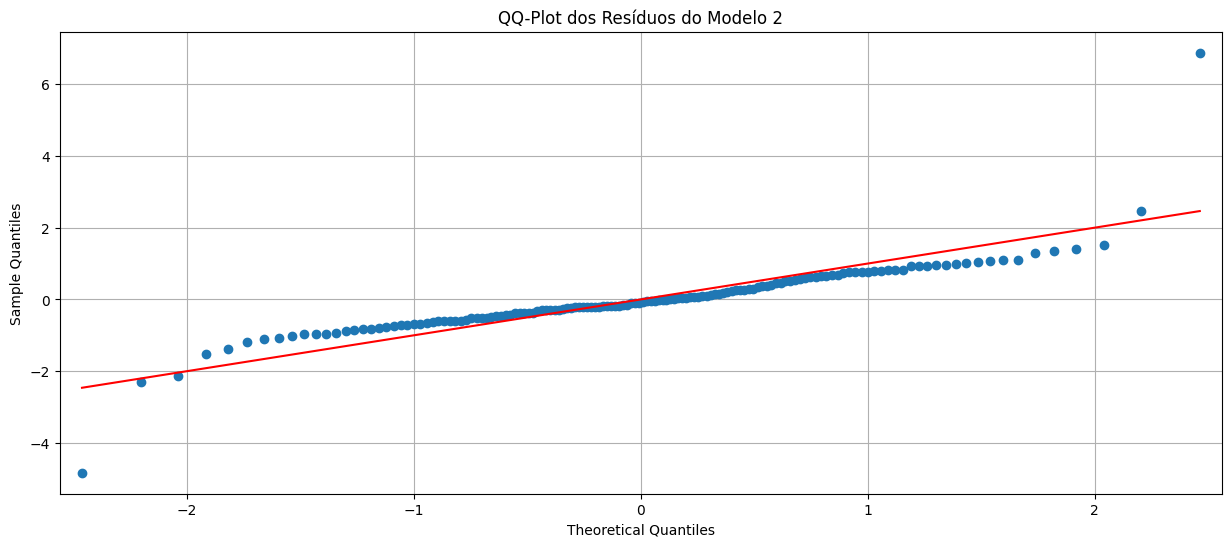

In [17]:
plt.figure(figsize=(rcParams['figure.figsize'][0]*0.6, rcParams['figure.figsize'][1]))
sm.qqplot(E_mod2_clean, line='s', fit=True)
plt.title('QQ-Plot dos Resíduos do Modelo 2')
plt.grid(True)
plt.show()

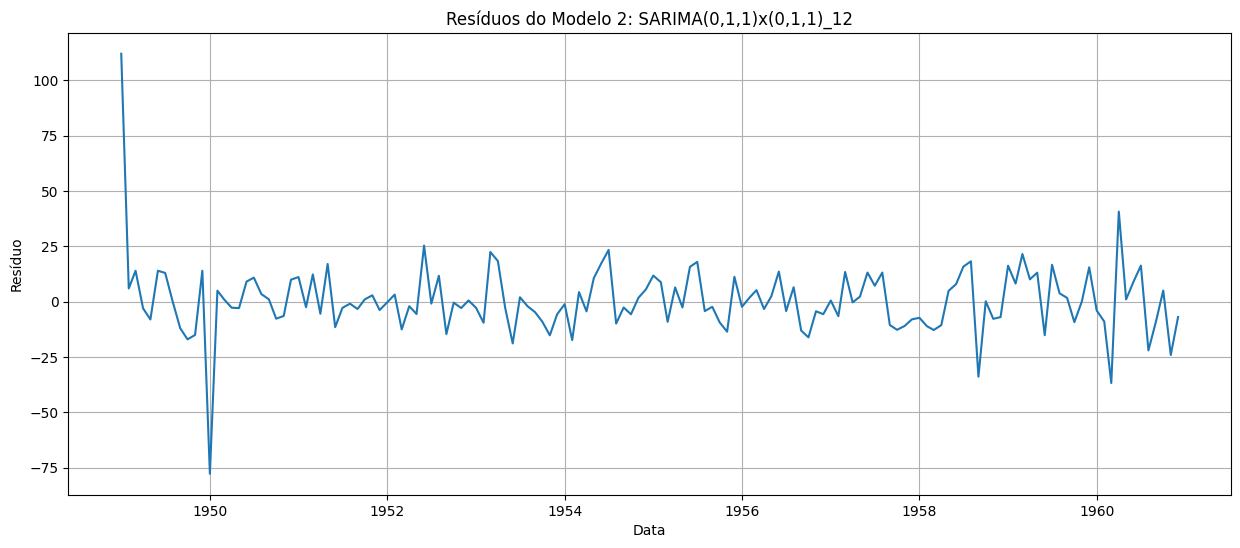

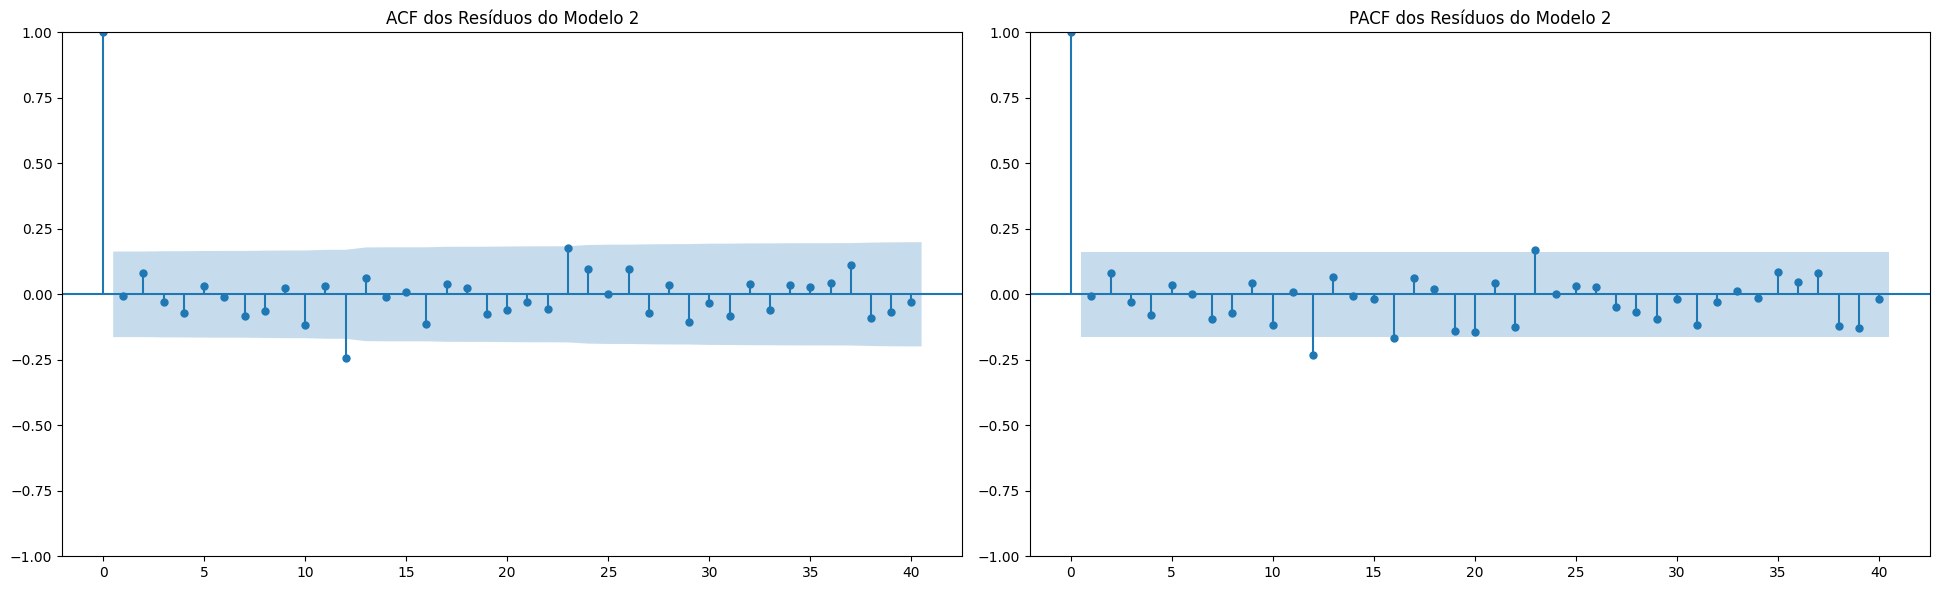

<Figure size 900x600 with 0 Axes>

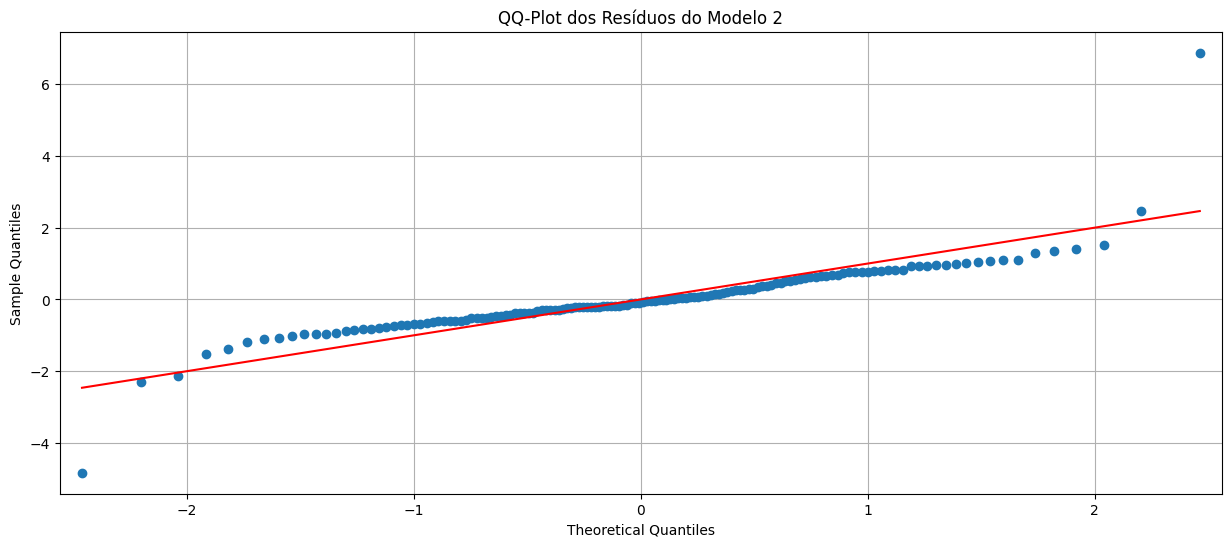

In [18]:
#E_mod2 = auto_model.resid
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()

    plt.figure(figsize=(rcParams['figure.figsize']))
    plt.plot(E_mod2_clean)
    plt.title('Resíduos do Modelo 2: SARIMA(0,1,1)x(0,1,1)_12')
    plt.xlabel('Data')
    plt.ylabel('Resíduo')
    plt.grid(True)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(rcParams['figure.figsize'][0]*1.3, rcParams['figure.figsize'][1]))
    plot_acf(E_mod2_clean, lags=40, ax=axes[0], title='ACF dos Resíduos do Modelo 2')
    plot_pacf(E_mod2_clean, lags=40, ax=axes[1], title='PACF dos Resíduos do Modelo 2')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(rcParams['figure.figsize'][0]*0.6, rcParams['figure.figsize'][1]))
    sm.qqplot(E_mod2_clean, line='s', fit=True)
    plt.title('QQ-Plot dos Resíduos do Modelo 2')
    plt.grid(True)
    plt.show()


### 4.6. Teste KPSS para Resíduos do Modelo 2
Verifica a estacionaridade dos resíduos. H0: A série é estacionária.

In [19]:
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()
    if len(E_mod2_clean) > 0: # Garante que há dados para testar
        print('Teste KPSS para Resíduos do Modelo 2:')
        kpss_stat, p_value, lags, critical_values = kpss(E_mod2_clean, regression='c')
        print(f'Estatística do teste: {kpss_stat:.4f}')
        print(f'p-valor: {p_value:.4f}')
        print('Valores Críticos:')
        for key, value in critical_values.items():
            print(f'{key}: {value:.4f}')
        if p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO ESTACIONÁRIOS.")
    else:
        print("Não há resíduos válidos para testar no Modelo 2.")

Teste KPSS para Resíduos do Modelo 2:
Estatística do teste: 0.0803
p-valor: 0.1000
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Conclusão: Falha ao rejeitar H0. Os resíduos são ESTACIONÁRIOS.


### 4.7. Teste Ljung-Box para Resíduos do Modelo 2
Verifica a independência (ausência de autocorrelação) dos resíduos. H0: Os resíduos são ruído branco.

In [20]:
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()
    if len(E_mod2_clean) > 0: # Garante que há dados para testar
        print('Teste Ljung-Box para Resíduos do Modelo 2:')
        ljung_box_result = sm.stats.acorr_ljungbox(E_mod2_clean, lags=[min(40, len(E_mod2_clean) - 1)], return_df=True)
        print(ljung_box_result)
        if ljung_box_result['lb_pvalue'].iloc[0] > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são INDEPENDENTES (ruído branco).")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO INDEPENDENTES.")
    else:
        print("Não há resíduos válidos para testar no Modelo 2.")

Teste Ljung-Box para Resíduos do Modelo 2:
      lb_stat  lb_pvalue
40  41.382145   0.410136
Conclusão: Falha ao rejeitar H0. Os resíduos são INDEPENDENTES (ruído branco).


### 4.8. Teste Shapiro-Wilk para Resíduos do Modelo 2
Verifica a normalidade dos resíduos. H0: Os resíduos são normalmente distribuídos.

In [21]:
if E_mod2 is not None:
    E_mod2_clean = E_mod2.dropna()
    if len(E_mod2_clean) >= 3:
        print('Teste Shapiro-Wilk para Resíduos do Modelo 2:')
        shapiro_stat, shapiro_p_value = shapiro(E_mod2_clean)
        print(f'Estatística do teste: {shapiro_stat:.4f}')
        print(f'p-valor: {shapiro_p_value:.4f}')
        if shapiro_p_value > 0.05:
            print("Conclusão: Falha ao rejeitar H0. Os resíduos são NORMALMENTE DISTRIBUÍDOS.")
        else:
            print("Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.")
    else:
        print("Não há dados suficientes nos resíduos para o teste Shapiro-Wilk no Modelo 2.")

Teste Shapiro-Wilk para Resíduos do Modelo 2:
Estatística do teste: 0.8021
p-valor: 0.0000
Conclusão: Rejeitamos H0. Os resíduos NÃO SÃO NORMALMENTE DISTRIBUÍDOS.


## 5. Resumos dos Modelos Ajustados
Nesta seção, apresentamos os sumários dos modelos SARIMA ajustados, que contêm informações cruciais como os coeficientes do modelo, seus erros padrão, p-valores, e métricas de ajuste como AIC e BIC.

In [22]:
print("\nSumário do Modelo 1: SARIMA(1,1,0)x(0,1,0)_12")
print(modelo1.summary())


Sumário do Modelo 1: SARIMA(1,1,0)x(0,1,0)_12
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -504.684
Date:                            Wed, 01 Jul 2026   AIC                           1013.368
Time:                                    21:59:48   BIC                           1019.103
Sample:                                01-01-1949   HQIC                          1015.698
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3096      0.074     -4.190      0.000      -0.454 

In [23]:
print("\nSumário do Modelo 2: SARIMA(1,1,1)x(0,1,0)_12")
print(modelo2.summary())


Sumário do Modelo 2: SARIMA(1,1,1)x(0,1,0)_12
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -457.315
Date:                            Wed, 01 Jul 2026   AIC                            920.631
Time:                                    21:59:51   BIC                            928.917
Sample:                                01-01-1949   HQIC                           923.995
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3175      0.073     -4.342      0.000      -0.461 

## 6. Busca Automática de Ordem SARIMA (auto_arima)
A função `auto_arima` do `pmdarima` é uma ferramenta poderosa para automatizar a busca das melhores ordens para o modelo SARIMA, testando diversas combinações e selecionando a que minimiza o AIC (ou outro critério).

In [24]:
print("\nIniciando busca automática de ordem para SARIMA (auto_arima)...")
# `d` e `D` são fixados pelos valores encontrados
# `start_p`, `start_q`, `start_P`, `start_Q` definem o início da busca
# `max_p`, `max_q`, `max_P`, `max_Q` definem os limites superiores
# `m` é o período sazonal
# `trace=True` exibe o progresso
# `stepwise=True` usa um algoritmo mais eficiente de busca
auto_model = auto_arima(x, 
                        d=d, D=D, 
                        start_p=0, start_q=0, 
                        max_p=3, max_q=3, 
                        start_P=0, start_Q=0, 
                        max_P=2, max_Q=2, 
                        m=m, 
                        seasonal=True, # Define que é um modelo sazonal
                        trace=True, 
                        error_action='ignore',  
                        suppress_warnings=True, 
                        stepwise=True)

print("\nSumário do Modelo SARIMA Sugerido por auto_arima:")
print(auto_model.summary())
print(f"Ordem (p,d,q) sugerida por auto_arima: {auto_model.order}")
print(f"Ordem sazonal (P,D,Q) sugerida por auto_arima: {auto_model.seasonal_order}")


Iniciando busca automática de ordem para SARIMA (auto_arima)...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.12 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.12 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.22 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.26 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.38 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.22 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.37 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.54 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.30 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.16 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.85 sec
 ARIMA(0,1,1)(1,1,1)[12]       

## 7. Realizando Previsões com o Melhor Modelo
Uma vez que o modelo é ajustado e validado, seu principal objetivo é fazer previsões para valores futuros da série temporal. Usaremos o modelo com melhor desempenho (menor AIC/BIC e resíduos de ruído branco) para realizar previsões.

Vamos plotar as previsões juntamente com a série histórica e os intervalos de confiança, que representam a incerteza da previsão.

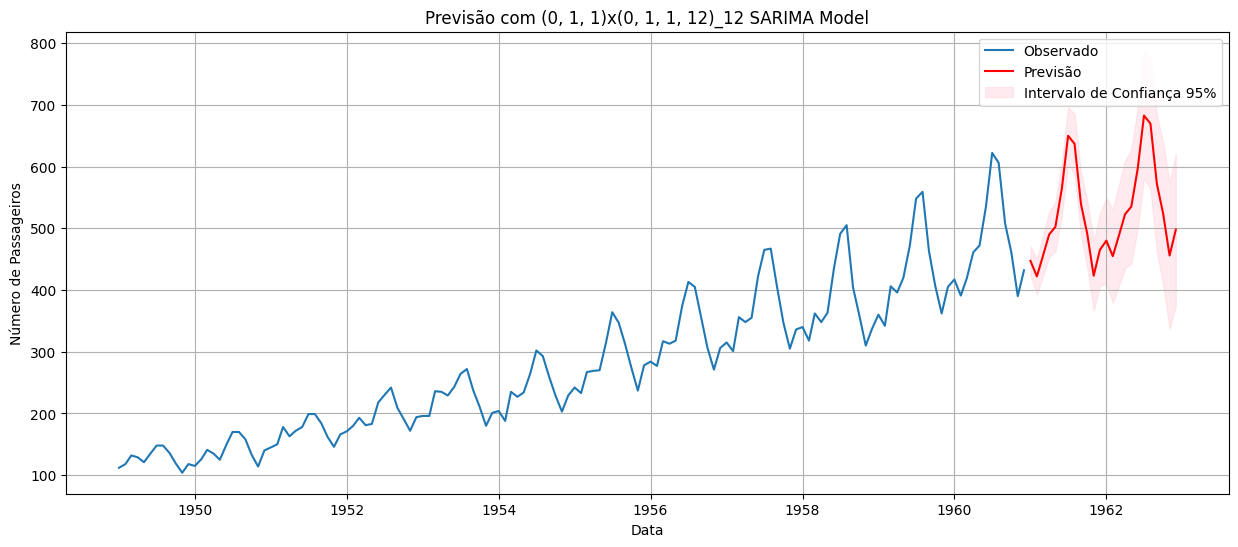

In [25]:
best_model = modelo2 

forecast_steps = 24 # Prever os próximos 24 meses (2 anos)

# Gerar o índice para as previsões
last_date = x.index[-1]
# O '+ 1' em periods inclui a última data, e o '[1:]' a remove para começar após a última data observada.
forecast_index = pd.date_range(start=last_date, periods=forecast_steps + 1, freq='MS')[1:] 

# Realizar a previsão
forecast_results = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast_results.predicted_mean
forecast_conf_int = forecast_results.conf_int()

# Plotando a série observada e a previsão
plt.figure(figsize=(plt.rcParams['figure.figsize'])) # Usando plt.rcParams diretamente
plt.plot(x, label='Observado')
plt.plot(forecast_index, forecast_mean, label='Previsão', color='red')
plt.fill_between(forecast_index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confiança 95%')

# Acessando order e seasonal_order através do atributo .model do SARIMAXResults
plt.title(f'Previsão com {best_model.model.order}x{best_model.model.seasonal_order}_{m} SARIMA Model')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.grid(True)
plt.show()

## 8. Conclusões Finais
Neste notebook, abordamos a modelagem de séries temporais com o modelo SARIMA, uma ferramenta essencial para lidar com dados que apresentam sazonalidade.

Passamos por todas as etapas cruciais:
1.  Visualização e Decomposição: Entendendo a estrutura da série (tendência, sazonalidade, resíduo).
2.  Determinação das Ordens: Utilizando testes estatísticos (KPSS) e funções auxiliares (`ndiffs`, `nsdiffs`) para encontrar as ordens de diferenciação não sazonal ($d$) e sazonal ($D$).
3.  Análise de ACF e PACF: Interpretando os correlogramas da série diferenciada para identificar as ordens $p, q, P, Q$.
4.  Ajuste e Validação do Modelo: Ajustando modelos SARIMA candidatos e, mais importante, analisando se seus resíduos se comportam como ruído branco (estacionários, independentes, normais).
5.  Comparação de Modelos: Usando AIC e BIC para selecionar o modelo mais adequado, e mostrando o poder do `auto_arima` na automação deste processo.
6.  Previsão: Gerando e visualizando previsões futuras com intervalos de confiança.

A modelagem SARIMA é um processo iterativo que combina conhecimento teórico, análise visual e testes estatísticos. Ferramentas como `pmdarima` simplificam a busca pelos melhores parâmetros, mas a compreensão dos fundamentos é sempre a chave para uma modelagem robusta e previsões confiáveis.